This code is the same as cnn_test.ipynb but with two differences:
1) We manually selected, among the top 10 models, those showing the smallest gap between training and validation loss and we called them "best models";
2) We removed, from the top 10 models ensemble, those whose minimum validation loss appears as an isolated spike and we called them "no spike models".

# Import the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xskillscore as xs
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import dill
import gc

2026-06-17 10:57:40.955487: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-17 10:57:40.964128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781686660.973850   55046 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781686660.976713   55046 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781686660.984290   55046 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Upload file pickle

In [2]:
with open('cnn_obs.pkl', 'rb') as file:
    hadisst_dic = dill.load(file)
    ncep_ncar_dic = dill.load(file)

In [3]:
with open('results_per_leadtime.pkl', 'rb') as file:
    results_per_leadtime = dill.load(file)

# Define the months for the CNN input; define the number of lead time

In [4]:
months_name = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG']
number_lead_time = 6

# Plot of Training and Validation loss


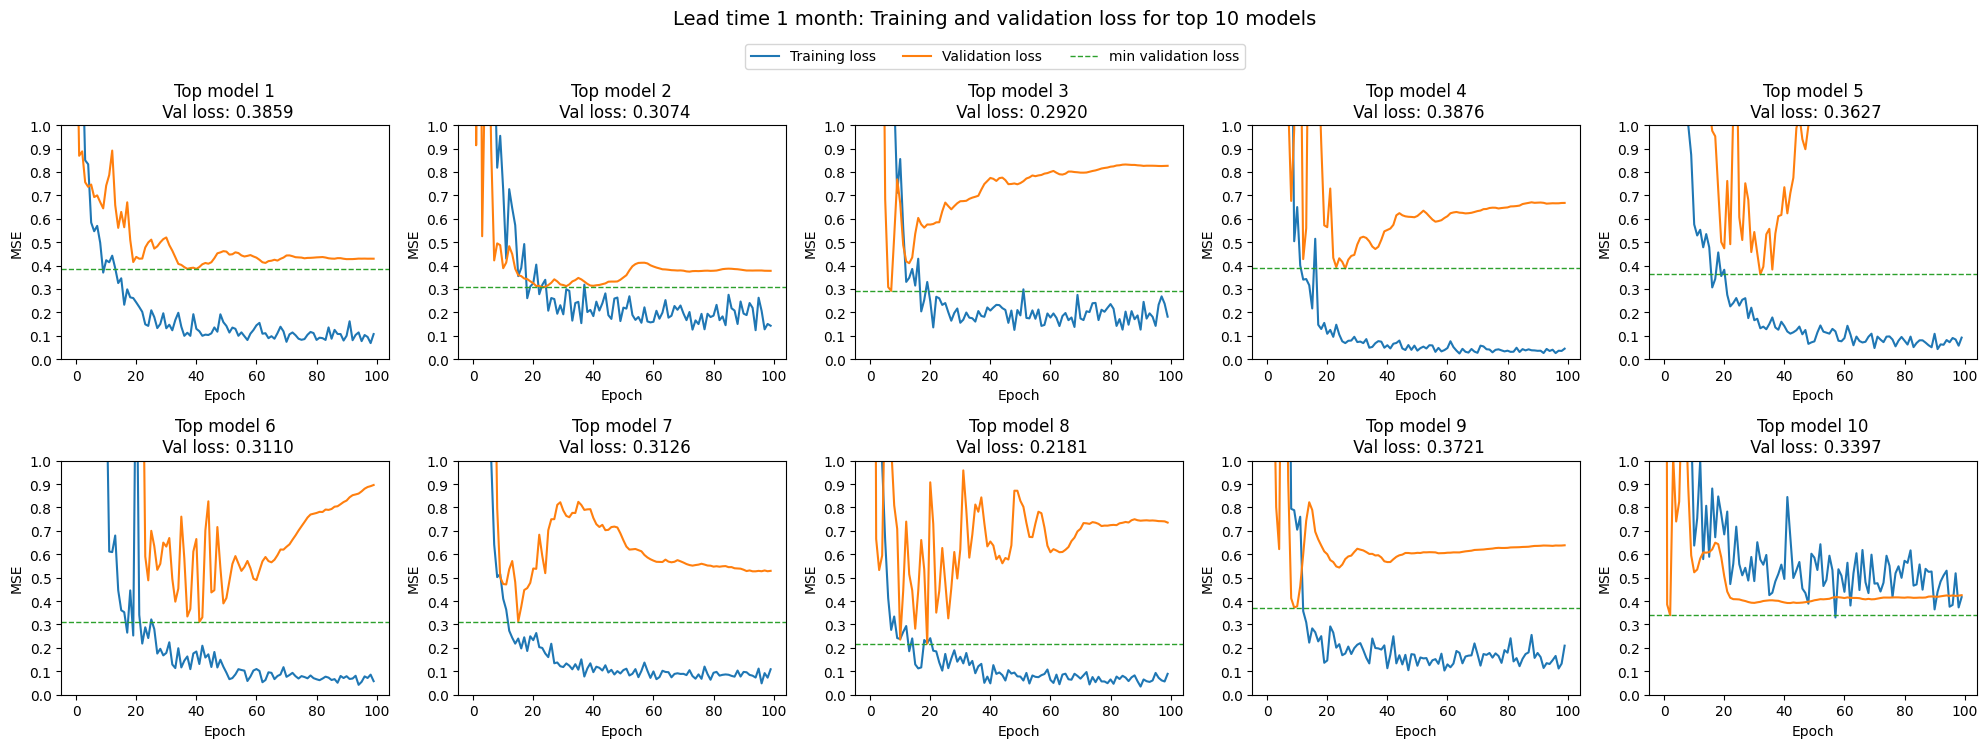

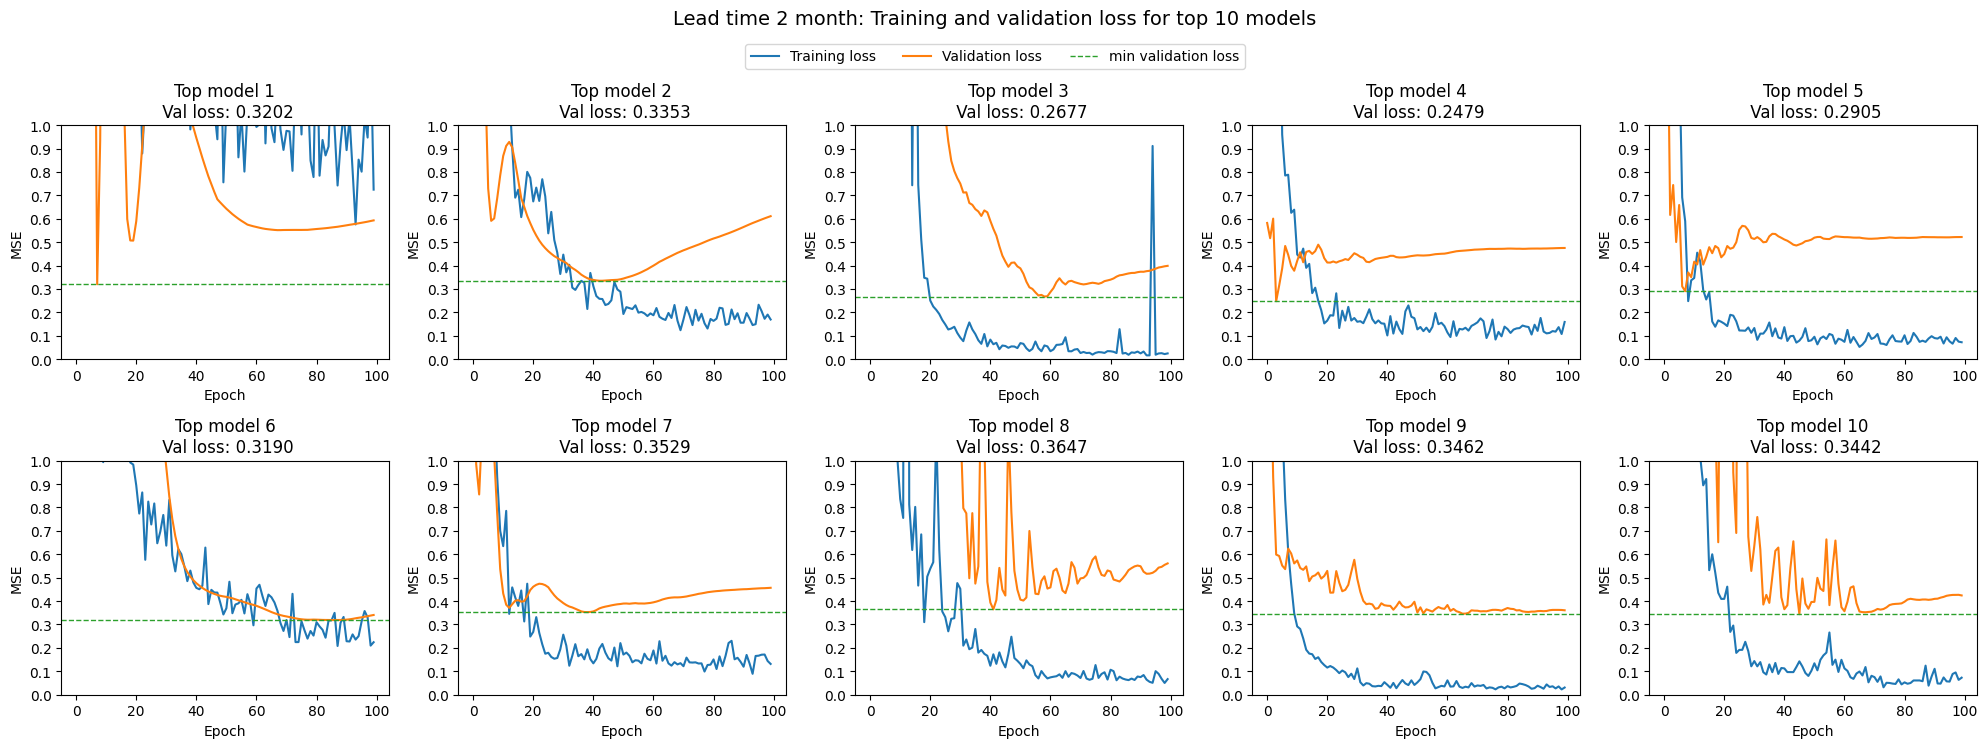

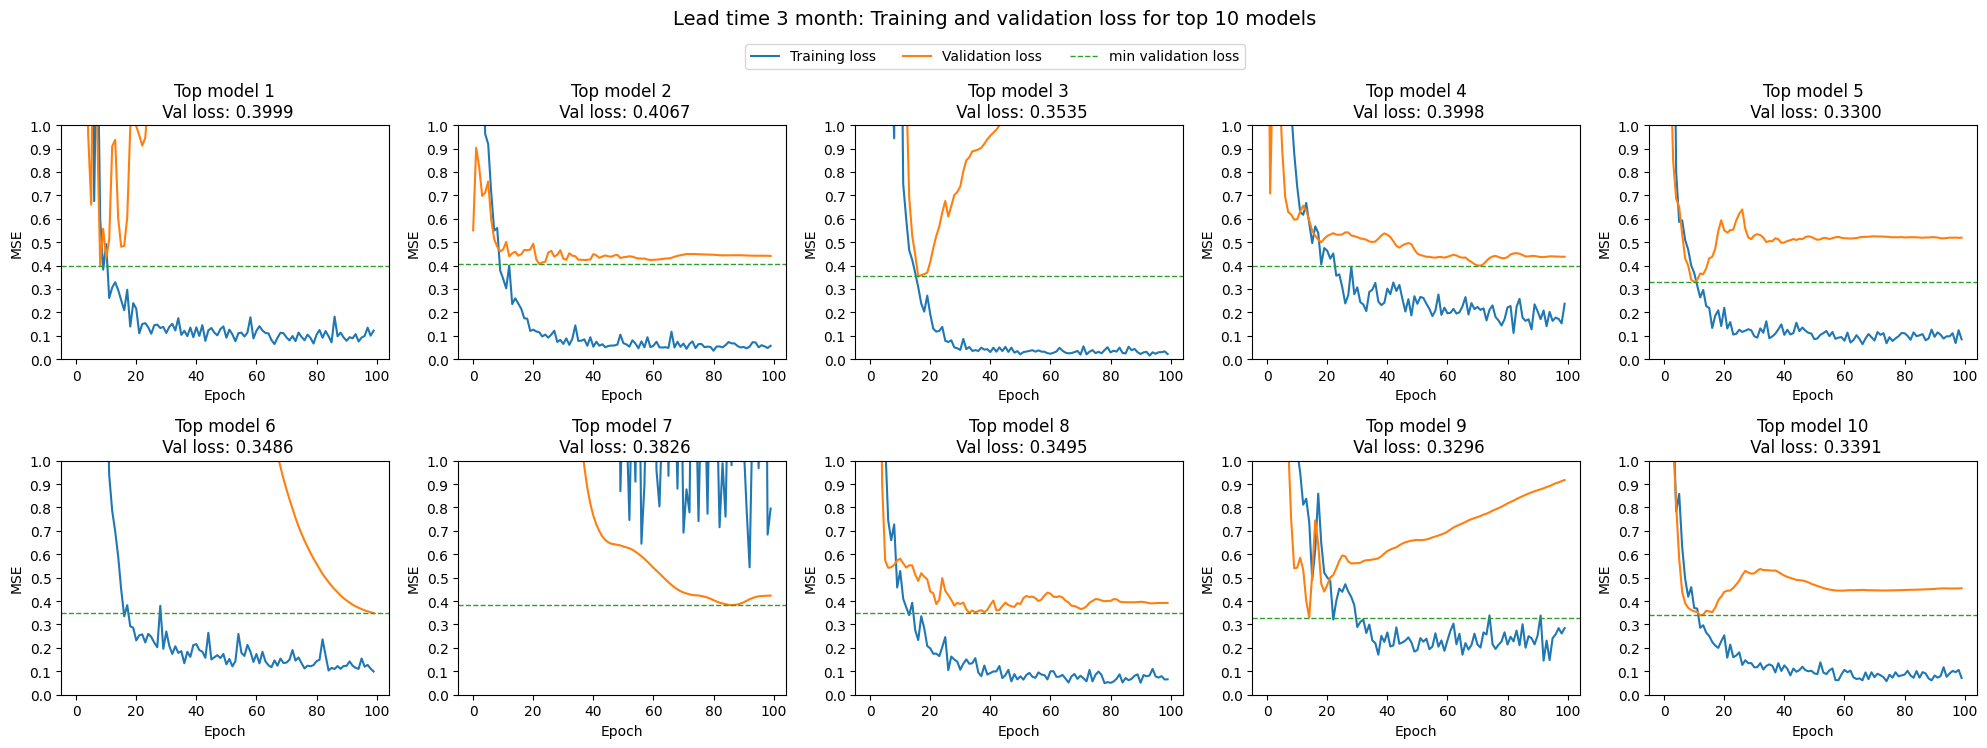

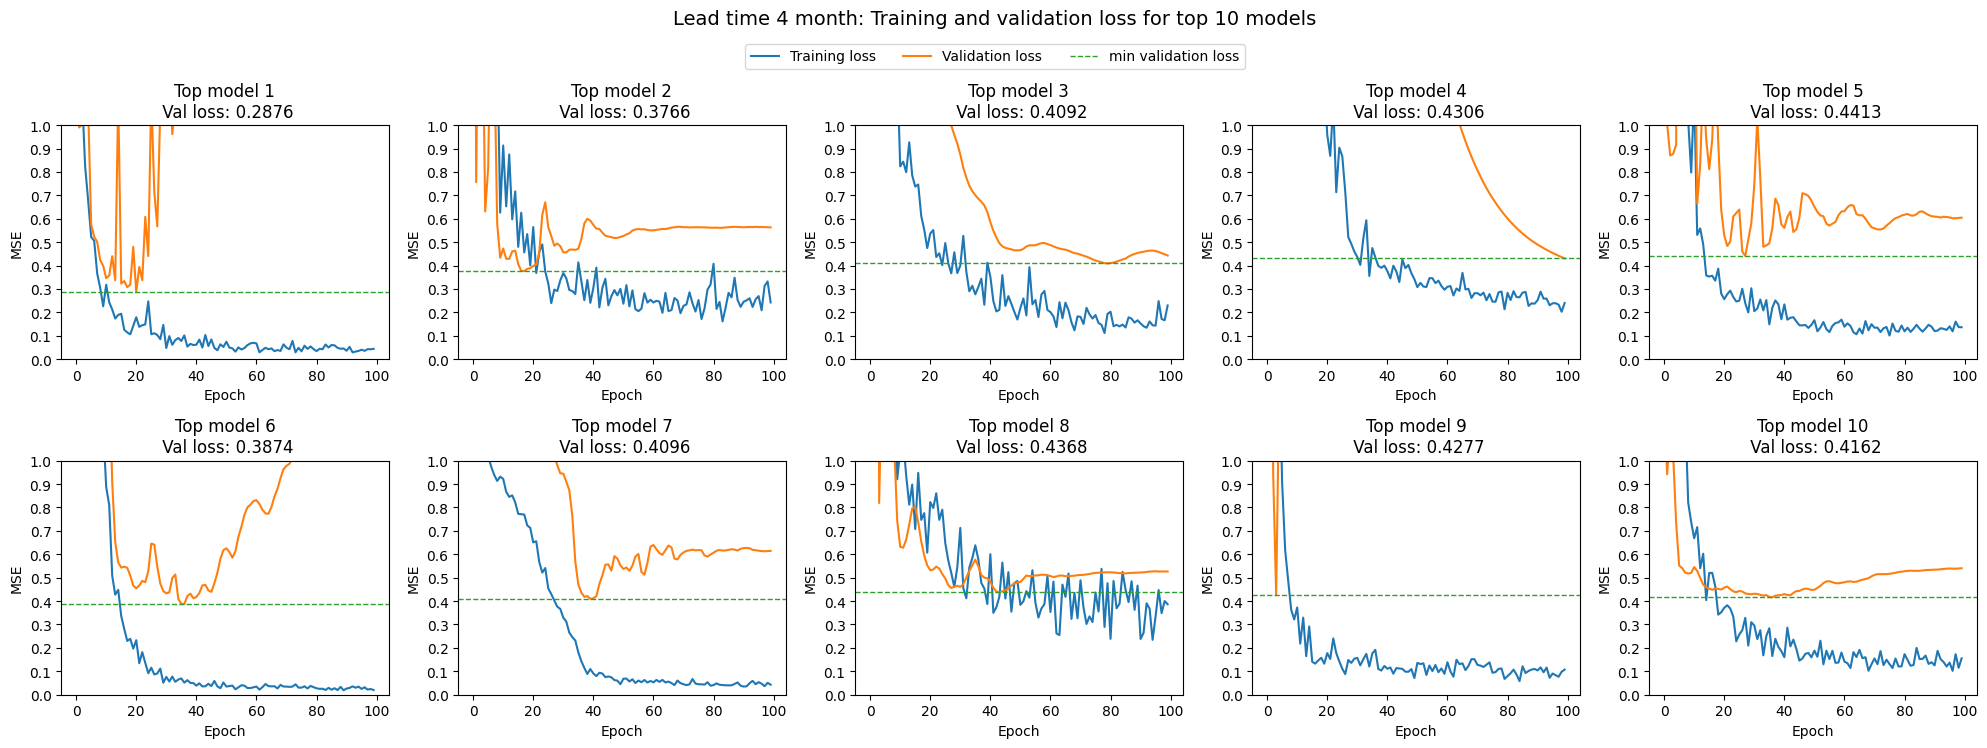

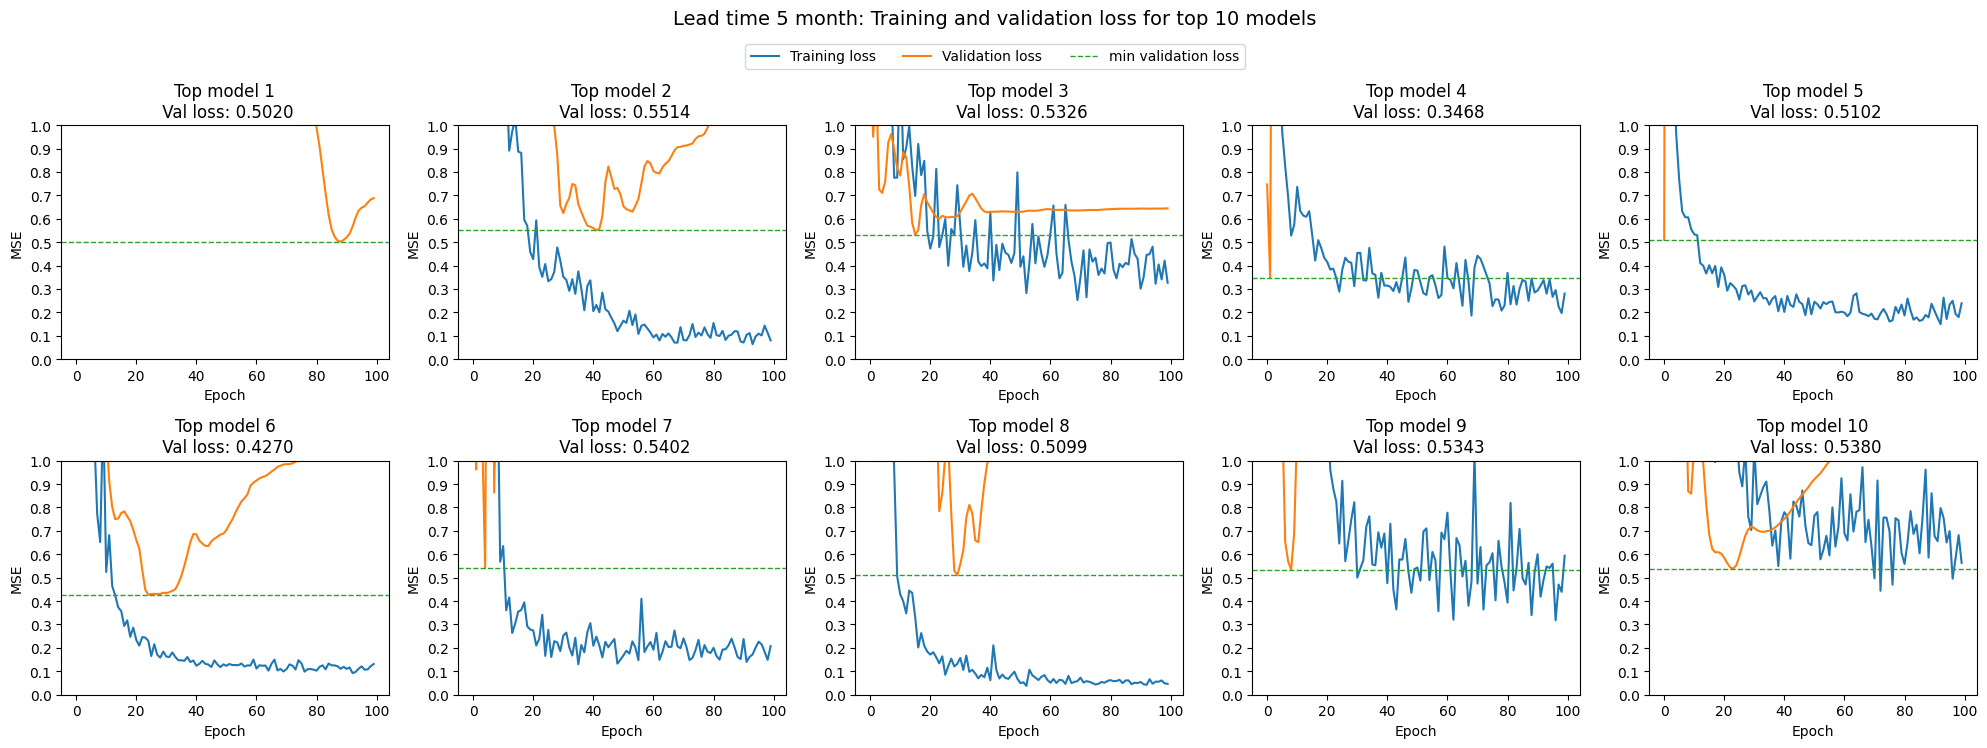

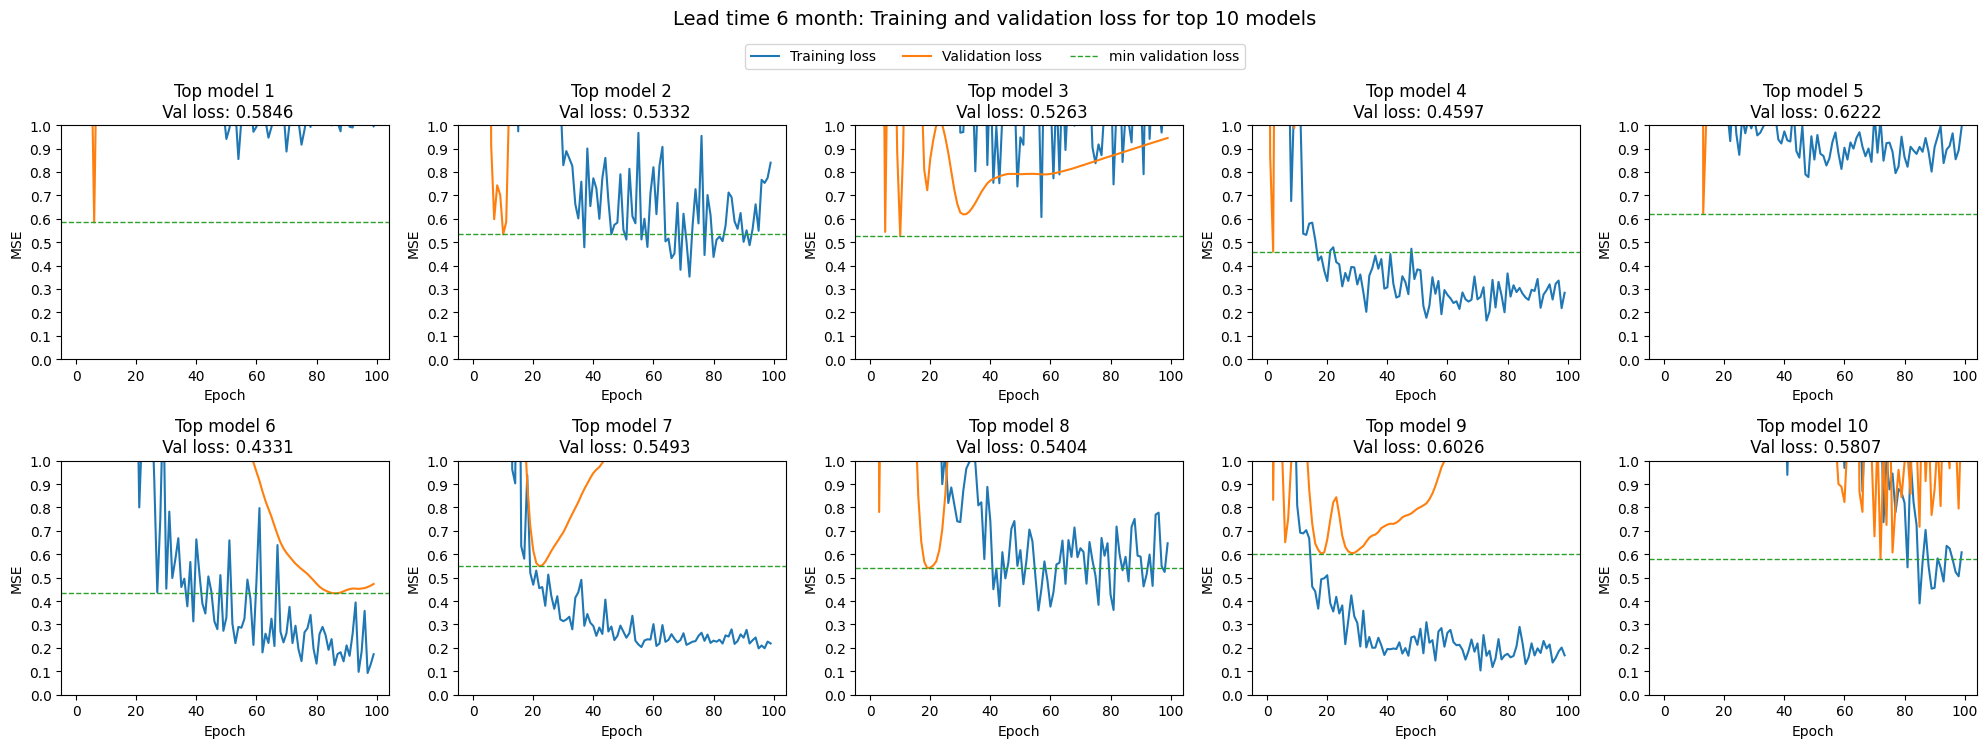

In [5]:
#Plot of training loss and validation loss as the learning rate increases
#The minimum validation loss is the chosen one
for j in range(1,number_lead_time+1):
    top_histories = results_per_leadtime[j]['top_histories']
    top_scores = results_per_leadtime[j]['top_scores']
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, (hist, ax) in enumerate(zip(top_histories, axes)):
        ax.plot(hist['loss'], label='Training loss', color='C0')
        ax.plot(hist['val_loss'], label='Validation loss', color='C1')
        ax.axhline(top_scores[i],linewidth=1, linestyle='--',label='min validation loss',color='C2')
        ax.set_ylim(0,1)
        ax.set_xticks(np.arange(0,110,20))
        ax.set_yticks(np.arange(0,1.05,0.1))
        ax.set_title(f'Top model {i+1}\n Val loss: {top_scores[i]:.4f}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE')
    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 0.945))
    # Title
    plt.suptitle(f'Lead time {j} month: Training and validation loss for top 10 models', fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# 1. BEST MODELS

## Manual selection of the best models

In [6]:
list_best_models = [[2,8],[6],[4],[8],[3],[6,10]]

In [7]:
# Explicit the hyperparameters at each lead time
print("Hyperparameters of the best top models for each lead time \n")
for j in range(1,number_lead_time+1):
    current_best_model = list_best_models[j-1]
    
    #Save the best parameters and weights
    results_per_leadtime[j]['best_models_params'] = []
    results_per_leadtime[j]['best_models_weights'] = []

    for i in current_best_model:
        #Best parameters
        best_models_params = results_per_leadtime[j]['top_models_params'][i-1]
        results_per_leadtime[j]['best_models_params'].append(best_models_params)
        #Best weights
        best_models_weights = results_per_leadtime[j]['top_models_weights'][i-1]
        results_per_leadtime[j]['best_models_weights'].append(best_models_weights)

        print(f"Lead time {j}, model number {i}")
        print(best_models_params)
        print("-" * 50) # Separator line for readability

Hyperparameters of the best top models for each lead time 

Lead time 1, model number 2
{'batch_size': 16, 'dense_units': 150, 'filter_size': [3, 3], 'initial_dropout': 0.1, 'initial_filters': 8, 'learning_rate': 0.001}
--------------------------------------------------
Lead time 1, model number 8
{'batch_size': 8, 'dense_units': 50, 'filter_size': [5, 5], 'initial_dropout': 0, 'initial_filters': 8, 'learning_rate': 0.001}
--------------------------------------------------
Lead time 2, model number 6
{'batch_size': 64, 'dense_units': 50, 'filter_size': [5, 5], 'initial_dropout': 0.3, 'initial_filters': 32, 'learning_rate': 0.001}
--------------------------------------------------
Lead time 3, model number 4
{'batch_size': 16, 'dense_units': 100, 'filter_size': [3, 3], 'initial_dropout': 0.3, 'initial_filters': 32, 'learning_rate': 0.001}
--------------------------------------------------
Lead time 4, model number 8
{'batch_size': 16, 'dense_units': 150, 'filter_size': [3, 3], 'initial_

## Performance metrics on training and validation (best models)

In [8]:
#Reconstruct the best 10 predictions models on training and validation to compute the performance metrics

for j in range(1,number_lead_time+1):

    #TRAINING DATA
    X_train = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly training'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly training'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly training']], #SLP
                        dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')
    y_train = hadisst_dic['SON (di west-east)']['dipole index training'].fillna(0)
    
    #VALIDATION DATA
    X_val = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly validation'], #SLP
                      ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly validation'], #SLP
                      ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly validation']], #SLP
                      dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')
    y_val = hadisst_dic['SON (di west-east)']['dipole index validation'].fillna(0)
    
    X_train_tensor = tf.constant(X_train.values.astype('float32'))
    y_train_np = y_train.values.astype('float32')
    X_val_tensor = tf.constant(X_val.values.astype('float32'))
    y_val_np = y_val.values.astype('float32')
    
    final_best_train_predictions = []
    final_best_val_predictions = []

    for weights, params in zip(results_per_leadtime[j]['best_models_weights'], results_per_leadtime[j]['best_models_params']):
        tf.keras.backend.clear_session()

        # Same architecture
        model = models.Sequential()
        filters = params['initial_filters']
        dropout = params['initial_dropout']
        # First block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', input_shape=X_train_tensor.shape[1:], padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        filters *= 2
        dropout += 0.1
        # Second block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        filters *= 2
        dropout += 0.1
        # Third block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        model.add(layers.Flatten())
        model.add(layers.Dense(params['dense_units'], activation='elu'))
        model.add(layers.Dense(1))

        model.compile(optimizer=optimizers.Adam(learning_rate=params['learning_rate']), loss='mse', metrics=['mae'])
        model.predict(X_train_tensor[:1], verbose=0)
        model.set_weights(weights)

        final_best_train_predictions.append(model.predict(X_train_tensor, verbose=0))
        final_best_val_predictions.append(model.predict(X_val_tensor, verbose=0))
        
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    results_per_leadtime[j]['final_best_train_predictions'] = final_best_train_predictions
    results_per_leadtime[j]['final_best_val_predictions'] = final_best_val_predictions

2026-06-17 10:57:48.396455: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/sarabeltrami9/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Function to compute the performance metrics
def print_metrics_single_leadtime(prediction, target, name_train_val_test, lead_time_index):
    mae = xs.mae(prediction, target, dim='time').values
    mse = xs.mse(prediction, target, dim='time').values
    rmse = xs.rmse(prediction, target, dim='time').values
    corr = xs.pearson_r(prediction, target, dim='time').values
    r2 = xs.r2(prediction, target, dim='time').values

    print(f"{name_train_val_test}, lead time {lead_time_index}: "
          f"MAE: {mae:.4f}; "
          f"MSE: {mse:.4f}; "
          f"RMSE: {rmse:.4f}; "
          f"Pearson ACC: {corr:.4f}; "
          f"R²: {r2:.4f}")

for j in range(len(results_per_leadtime)):
    ensemble_train = np.mean(results_per_leadtime[j+1]['final_best_train_predictions'], axis=0)
    ensemble_val = np.mean(results_per_leadtime[j+1]['final_best_val_predictions'], axis=0)

    ensemble_train = xr.DataArray(ensemble_train.squeeze(), dims=('time'), coords={'time': y_train.time})
    ensemble_val = xr.DataArray(ensemble_val.squeeze(), dims=('time'), coords={'time': y_val.time})
    
    results_per_leadtime[j+1]['ensemble_best_train'] = ensemble_train
    results_per_leadtime[j+1]['ensemble_best_val'] = ensemble_val
    
    print_metrics_single_leadtime(ensemble_train, y_train, 'TRAINING', j+1)
    print_metrics_single_leadtime(ensemble_val, y_val, 'VALIDATION', j+1)
    print("-" * 50) # Separator line for readability

TRAINING, lead time 1: MAE: 0.3532; MSE: 0.1778; RMSE: 0.4217; Pearson ACC: 0.9759; R²: 0.8632
VALIDATION, lead time 1: MAE: 0.3134; MSE: 0.1703; RMSE: 0.4127; Pearson ACC: 0.9071; R²: 0.6849
--------------------------------------------------
TRAINING, lead time 2: MAE: 0.5159; MSE: 0.4031; RMSE: 0.6349; Pearson ACC: 0.7947; R²: 0.5805
VALIDATION, lead time 2: MAE: 0.4231; MSE: 0.3190; RMSE: 0.5648; Pearson ACC: 0.8411; R²: -0.0378
--------------------------------------------------
TRAINING, lead time 3: MAE: 0.6242; MSE: 0.6280; RMSE: 0.7925; Pearson ACC: 0.7136; R²: 0.4586
VALIDATION, lead time 3: MAE: 0.4381; MSE: 0.3998; RMSE: 0.6323; Pearson ACC: 0.7778; R²: -0.6999
--------------------------------------------------
TRAINING, lead time 4: MAE: 0.9456; MSE: 1.2873; RMSE: 1.1346; Pearson ACC: 0.8321; R²: 0.5324
VALIDATION, lead time 4: MAE: 0.5513; MSE: 0.4368; RMSE: 0.6609; Pearson ACC: 0.7150; R²: 0.2601
--------------------------------------------------
TRAINING, lead time 5: MAE

## Testing of the CNN (best models)

In [10]:
results_per_leadtime_testing = {}

for j in range(1,number_lead_time+1):
    # TESTING DATA
    X_test = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly testing'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly testing'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly testing']], #SLP
                        dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')
    y_test = hadisst_dic['SON (di west-east)']['dipole index testing'].fillna(0)
    
    X_test_tensor = tf.constant(X_test.values.astype('float32'))
    y_test_np = y_test.values.astype('float32')
    
    # Reconstruct the top 10 models and 'validate' them on test set
    final_best_test_predictions = []

    for i, (weights, params) in enumerate(zip(results_per_leadtime[j]['best_models_weights'], results_per_leadtime[j]['best_models_params'])):
        
        tf.keras.backend.clear_session()

        # Reconstruct the same architecture
        model = models.Sequential()
        filters = params['initial_filters']
        dropout = params['initial_dropout']

        # First Conv Block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', input_shape=X_test_tensor.shape[1:], padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        # Second Conv Block
        filters *= 2
        dropout += 0.1
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        # Third Conv Block
        filters *= 2
        dropout += 0.1
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        model.add(layers.Flatten())
        model.add(layers.Dense(params['dense_units'], activation='elu'))
        model.add(layers.Dense(1))

        model.compile(optimizer=optimizers.Adam(learning_rate=params['learning_rate']), loss='mse', metrics=['mae'])
        model.predict(X_test_tensor[:1], verbose=0) #It serves as initialization
        
        # Upload weights saved during the training
        model.set_weights(weights)
        # Prediction on test set
        pred = model.predict(X_test_tensor, verbose=0)
        final_best_test_predictions.append(pred)

        test_loss, test_mae = model.evaluate(X_test_tensor, y_test_np, verbose=0)
        print(f"Model {i+1} — test MSE: {test_loss:.4f}, test MAE: {test_mae:.4f}")

        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # Final Ensemble for each lead time: mean of the top 10 models
    ensemble_best_prediction = np.mean(final_best_test_predictions, axis=0)
    ensemble_best_prediction = xr.DataArray(ensemble_best_prediction.squeeze(), dims=('time'),
                                coords={'time': y_test.time})
    results_per_leadtime_testing[j] = {'ensemble_best_prediction': ensemble_best_prediction}

/home/sarabeltrami9/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 — test MSE: 1.0200, test MAE: 0.8738
Model 2 — test MSE: 0.6901, test MAE: 0.6891
Model 1 — test MSE: 0.9742, test MAE: 0.8017
Model 1 — test MSE: 0.7845, test MAE: 0.7347
Model 1 — test MSE: 1.0414, test MAE: 0.9733
Model 1 — test MSE: 0.6119, test MAE: 0.6021
Model 1 — test MSE: 1.0884, test MAE: 0.8353
Model 2 — test MSE: 1.0301, test MAE: 0.7490


## Performance metrics for test set (best models)

In [11]:
for j in range(len(results_per_leadtime_testing)):
    print_metrics_single_leadtime(results_per_leadtime_testing[j+1]['ensemble_best_prediction'], y_test, 'TESTING', j+1)
    print("-" * 50) # Separator line for readability

TESTING, lead time 1: MAE: 0.6594; MSE: 0.6375; RMSE: 0.7984; Pearson ACC: 0.4047; R²: -1.5972
--------------------------------------------------
TESTING, lead time 2: MAE: 0.8017; MSE: 0.9742; RMSE: 0.9870; Pearson ACC: 0.6316; R²: 0.0693
--------------------------------------------------
TESTING, lead time 3: MAE: 0.7347; MSE: 0.7845; RMSE: 0.8857; Pearson ACC: -0.1873; R²: -6.7993
--------------------------------------------------
TESTING, lead time 4: MAE: 0.9733; MSE: 1.0414; RMSE: 1.0205; Pearson ACC: -0.1744; R²: -3.9410
--------------------------------------------------
TESTING, lead time 5: MAE: 0.6021; MSE: 0.6119; RMSE: 0.7823; Pearson ACC: 0.1802; R²: -5.1788
--------------------------------------------------
TESTING, lead time 6: MAE: 0.7765; MSE: 0.9644; RMSE: 0.9820; Pearson ACC: -0.0618; R²: -3.3838
--------------------------------------------------


## Plots of the best models

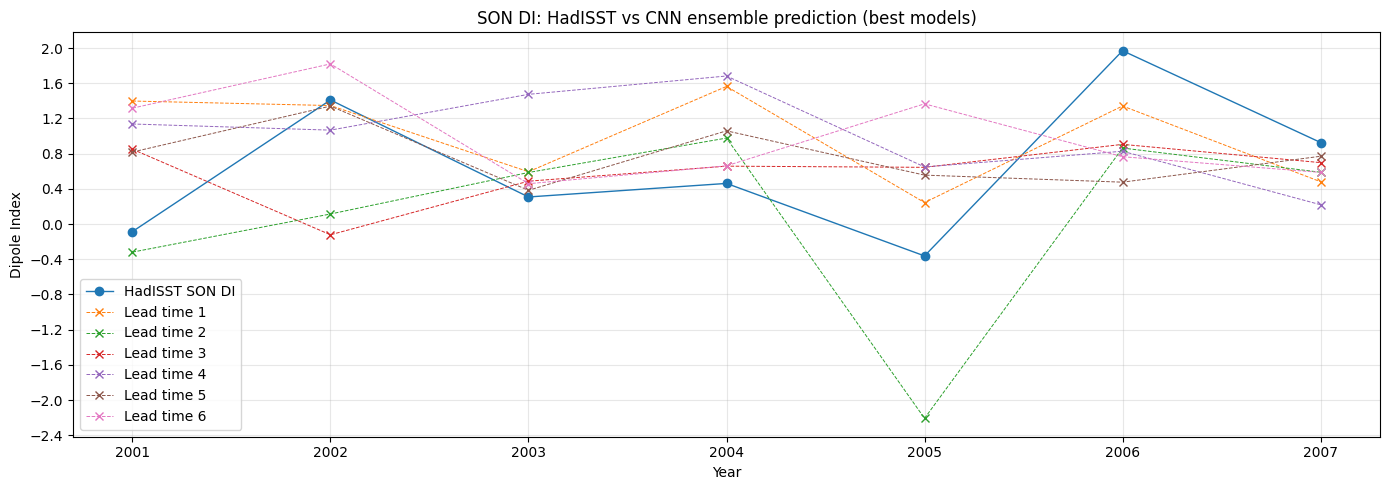

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test.time, y_test, color='C0', marker='o', label='HadISST SON DI', linewidth=1)

# Define the color list for each lead time
color_list = ['C1','C2','C3','C4','C5','C6']
for i in range(len(results_per_leadtime_testing)):
    ax.plot(y_test.time, results_per_leadtime_testing[i+1]['ensemble_best_prediction'], color=color_list[i], marker='x', linestyle='--',lw=0.7,label=f'Lead time {i+1}')

ax.set_xticks(y_test.time.values)
ax.set_yticks(np.arange(-2.4,2.4,0.4))
ax.set_xlabel('Year')
ax.set_ylabel('Dipole Index')
ax.set_title('SON DI: HadISST vs CNN ensemble prediction (best models)')
ax.legend(loc='best')
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

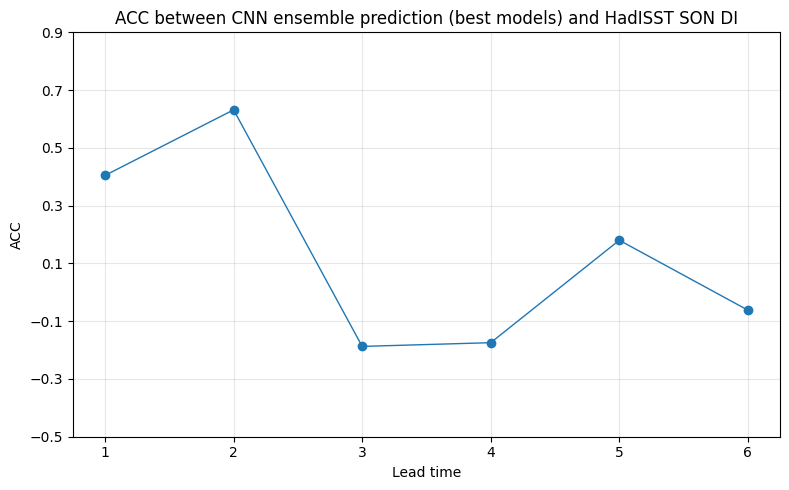

In [28]:
acc_values = []
for i in range(len(results_per_leadtime_testing)):
    pred = results_per_leadtime_testing[i+1]['ensemble_best_prediction']
    acc = xs.pearson_r(pred, y_test, dim='time').values
    acc_values.append(acc)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1,len(results_per_leadtime_testing)+1), acc_values, marker='o', color='C0', linewidth=1)
ax.set_xlabel('Lead time')
ax.set_ylabel('ACC')
ax.set_title('ACC between CNN ensemble prediction (best models) and HadISST SON DI')
ax.set_xticks(np.arange(1,len(results_per_leadtime_testing)+1))
ax.set_yticks(np.arange(-0.5,1.0,0.2))
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

# 2. NO SPIKE MODELS

## Manual selection of no spike models

In [14]:
list_no_spike_models = [[1,2,4,5,6,7,8,9],[2,3,5,6,7,8,9,10],[2,4,6,7,8,10],[1,2,3,4,5,6,7,8,10],[3],[6,10]]

In [15]:
# Explicit the hyperparameters at each lead time
print("Hyperparameters of the top models (no spike) for each lead time \n")
for j in range(1,number_lead_time+1):
    current_no_spike_model = list_no_spike_models[j-1]
    
    #Save the no_spike parameters and weights
    results_per_leadtime[j]['no_spike_models_params'] = []
    results_per_leadtime[j]['no_spike_models_weights'] = []

    for i in current_no_spike_model:
        #no_spike parameters
        no_spike_models_params = results_per_leadtime[j]['top_models_params'][i-1]
        results_per_leadtime[j]['no_spike_models_params'].append(no_spike_models_params)
        #Best weights
        no_spike_models_weights = results_per_leadtime[j]['top_models_weights'][i-1]
        results_per_leadtime[j]['no_spike_models_weights'].append(no_spike_models_weights)

        print(f"Lead time {j}, model number {i}")
        print(no_spike_models_params)
        print("-" * 50) # Separator line for readability

Hyperparameters of the top models (no spike) for each lead time 

Lead time 1, model number 1
{'batch_size': 8, 'dense_units': 50, 'filter_size': [3, 3], 'initial_dropout': 0.3, 'initial_filters': 16, 'learning_rate': 0.001}
--------------------------------------------------
Lead time 1, model number 2
{'batch_size': 16, 'dense_units': 150, 'filter_size': [3, 3], 'initial_dropout': 0.1, 'initial_filters': 8, 'learning_rate': 0.001}
--------------------------------------------------
Lead time 1, model number 4
{'batch_size': 16, 'dense_units': 100, 'filter_size': [3, 3], 'initial_dropout': 0.2, 'initial_filters': 8, 'learning_rate': 0.01}
--------------------------------------------------
Lead time 1, model number 5
{'batch_size': 8, 'dense_units': 150, 'filter_size': [5, 5], 'initial_dropout': 0.2, 'initial_filters': 8, 'learning_rate': 0.01}
--------------------------------------------------
Lead time 1, model number 6
{'batch_size': 16, 'dense_units': 150, 'filter_size': [5, 5], 'ini

## Performance metrics on training and validation (no spike models)

In [16]:
#Reconstruct the best 10 predictions models on training and validation to compute the performance metrics

for j in range(1,number_lead_time+1):

    #TRAINING DATA
    X_train = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly training'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly training'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly training']], #SLP
                        dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')
    y_train = hadisst_dic['SON (di west-east)']['dipole index training'].fillna(0)
    
    #VALIDATION DATA
    X_val = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly validation'], #SLP
                      ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly validation'], #SLP
                      ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly validation']], #SLP
                      dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')
    y_val = hadisst_dic['SON (di west-east)']['dipole index validation'].fillna(0)
    
    X_train_tensor = tf.constant(X_train.values.astype('float32'))
    y_train_np = y_train.values.astype('float32')
    X_val_tensor = tf.constant(X_val.values.astype('float32'))
    y_val_np = y_val.values.astype('float32')
    
    final_no_spike_train_predictions = []
    final_no_spike_val_predictions = []

    for weights, params in zip(results_per_leadtime[j]['no_spike_models_weights'], results_per_leadtime[j]['no_spike_models_params']):
        tf.keras.backend.clear_session()

        # Same architecture
        model = models.Sequential()
        filters = params['initial_filters']
        dropout = params['initial_dropout']
        # First block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', input_shape=X_train_tensor.shape[1:], padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        filters *= 2
        dropout += 0.1
        # Second block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        filters *= 2
        dropout += 0.1
        # Third block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        model.add(layers.Flatten())
        model.add(layers.Dense(params['dense_units'], activation='elu'))
        model.add(layers.Dense(1))

        model.compile(optimizer=optimizers.Adam(learning_rate=params['learning_rate']), loss='mse', metrics=['mae'])
        model.predict(X_train_tensor[:1], verbose=0)
        model.set_weights(weights)

        final_no_spike_train_predictions.append(model.predict(X_train_tensor, verbose=0))
        final_no_spike_val_predictions.append(model.predict(X_val_tensor, verbose=0))
        
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    results_per_leadtime[j]['final_no_spike_train_predictions'] = final_no_spike_train_predictions
    results_per_leadtime[j]['final_no_spike_val_predictions'] = final_no_spike_val_predictions

/home/sarabeltrami9/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
for j in range(len(results_per_leadtime)):
    ensemble_train = np.mean(results_per_leadtime[j+1]['final_no_spike_train_predictions'], axis=0)
    ensemble_val = np.mean(results_per_leadtime[j+1]['final_no_spike_val_predictions'], axis=0)

    ensemble_train = xr.DataArray(ensemble_train.squeeze(), dims=('time'), coords={'time': y_train.time})
    ensemble_val = xr.DataArray(ensemble_val.squeeze(), dims=('time'), coords={'time': y_val.time})
    
    results_per_leadtime[j+1]['ensemble_no_spike_train'] = ensemble_train
    results_per_leadtime[j+1]['ensemble_no_spike_val'] = ensemble_val
    
    print_metrics_single_leadtime(ensemble_train, y_train, 'TRAINING', j+1)
    print_metrics_single_leadtime(ensemble_val, y_val, 'VALIDATION', j+1)
    print("-" * 50) # Separator line for readability

TRAINING, lead time 1: MAE: 0.3904; MSE: 0.1885; RMSE: 0.4342; Pearson ACC: 0.9792; R²: 0.8287
VALIDATION, lead time 1: MAE: 0.4046; MSE: 0.2348; RMSE: 0.4846; Pearson ACC: 0.8554; R²: 0.6082
--------------------------------------------------
TRAINING, lead time 2: MAE: 0.2403; MSE: 0.0782; RMSE: 0.2796; Pearson ACC: 0.9851; R²: 0.9058
VALIDATION, lead time 2: MAE: 0.3874; MSE: 0.2459; RMSE: 0.4959; Pearson ACC: 0.8757; R²: 0.3675
--------------------------------------------------
TRAINING, lead time 3: MAE: 0.4158; MSE: 0.2510; RMSE: 0.5010; Pearson ACC: 0.9410; R²: 0.7448
VALIDATION, lead time 3: MAE: 0.4205; MSE: 0.2973; RMSE: 0.5453; Pearson ACC: 0.8254; R²: 0.2341
--------------------------------------------------
TRAINING, lead time 4: MAE: 0.3711; MSE: 0.1940; RMSE: 0.4405; Pearson ACC: 0.9636; R²: 0.7988
VALIDATION, lead time 4: MAE: 0.3631; MSE: 0.2375; RMSE: 0.4873; Pearson ACC: 0.9004; R²: 0.2919
--------------------------------------------------
TRAINING, lead time 5: MAE: 

## Testing of the CNN (no spike models)

In [18]:
for j in range(1,number_lead_time+1):
    # TESTING DATA
    X_test = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly testing'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly testing'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly testing']], #SLP
                        dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')
    y_test = hadisst_dic['SON (di west-east)']['dipole index testing'].fillna(0)
    
    X_test_tensor = tf.constant(X_test.values.astype('float32'))
    y_test_np = y_test.values.astype('float32')
    
    # Reconstruct the top 10 models and 'validate' them on test set
    final_no_spike_test_predictions = []

    for i, (weights, params) in enumerate(zip(results_per_leadtime[j]['no_spike_models_weights'], results_per_leadtime[j]['no_spike_models_params'])):
        
        tf.keras.backend.clear_session()

        # Reconstruct the same architecture
        model = models.Sequential()
        filters = params['initial_filters']
        dropout = params['initial_dropout']

        # First Conv Block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', input_shape=X_test_tensor.shape[1:], padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        # Second Conv Block
        filters *= 2
        dropout += 0.1
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        # Third Conv Block
        filters *= 2
        dropout += 0.1
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        model.add(layers.Flatten())
        model.add(layers.Dense(params['dense_units'], activation='elu'))
        model.add(layers.Dense(1))

        model.compile(optimizer=optimizers.Adam(learning_rate=params['learning_rate']), loss='mse', metrics=['mae'])
        model.predict(X_test_tensor[:1], verbose=0) #It serves as initialization
        
        # Upload weights saved during the training
        model.set_weights(weights)
        # Prediction on test set
        pred = model.predict(X_test_tensor, verbose=0)
        final_no_spike_test_predictions.append(pred)

        test_loss, test_mae = model.evaluate(X_test_tensor, y_test_np, verbose=0)
        print(f"Model {i+1} — test MSE: {test_loss:.4f}, test MAE: {test_mae:.4f}")

        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # Final Ensemble for each lead time: mean of the top 10 models
    ensemble_no_spike_prediction = np.mean(final_no_spike_test_predictions, axis=0)
    ensemble_no_spike_prediction = xr.DataArray(ensemble_no_spike_prediction.squeeze(), dims=('time'),
                                coords={'time': y_test.time})
    results_per_leadtime_testing[j].update({'ensemble_no_spike_prediction': ensemble_no_spike_prediction})

/home/sarabeltrami9/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 — test MSE: 1.3434, test MAE: 1.0677
Model 2 — test MSE: 1.0200, test MAE: 0.8738
Model 3 — test MSE: 1.1577, test MAE: 0.7015
Model 4 — test MSE: 0.7621, test MAE: 0.7067
Model 5 — test MSE: 0.2116, test MAE: 0.3693
Model 6 — test MSE: 0.1880, test MAE: 0.3185
Model 7 — test MSE: 0.6901, test MAE: 0.6891
Model 8 — test MSE: 0.8131, test MAE: 0.7198
Model 1 — test MSE: 0.5702, test MAE: 0.6100
Model 2 — test MSE: 0.5499, test MAE: 0.6445
Model 3 — test MSE: 0.3657, test MAE: 0.5443
Model 4 — test MSE: 0.9742, test MAE: 0.8017
Model 5 — test MSE: 0.6129, test MAE: 0.6107
Model 6 — test MSE: 0.5049, test MAE: 0.5958
Model 7 — test MSE: 0.3213, test MAE: 0.5192
Model 8 — test MSE: 0.9028, test MAE: 0.8924
Model 1 — test MSE: 1.4684, test MAE: 1.0818
Model 2 — test MSE: 0.7845, test MAE: 0.7347
Model 3 — test MSE: 2.0578, test MAE: 1.0893
Model 4 — test MSE: 1.8297, test MAE: 0.9496
Model 5 — test MSE: 0.6641, test MAE: 0.7524
Model 6 — test MSE: 0.5427, test MAE: 0.6608
Model 1 — 

## Performance metrics for test set (no spike models)

In [19]:
for j in range(len(results_per_leadtime_testing)):
    print_metrics_single_leadtime(results_per_leadtime_testing[j+1]['ensemble_no_spike_prediction'], y_test, 'TESTING', j+1)
    print("-" * 50) # Separator line for readability

TESTING, lead time 1: MAE: 0.5192; MSE: 0.4229; RMSE: 0.6503; Pearson ACC: 0.7261; R²: -0.6338
--------------------------------------------------
TESTING, lead time 2: MAE: 0.4948; MSE: 0.2911; RMSE: 0.5395; Pearson ACC: 0.7725; R²: -1.0702
--------------------------------------------------
TESTING, lead time 3: MAE: 0.7808; MSE: 0.8231; RMSE: 0.9073; Pearson ACC: 0.2026; R²: -1.9832
--------------------------------------------------
TESTING, lead time 4: MAE: 0.8156; MSE: 0.7743; RMSE: 0.8799; Pearson ACC: -0.5170; R²: -24.7603
--------------------------------------------------
TESTING, lead time 5: MAE: 0.6021; MSE: 0.6119; RMSE: 0.7823; Pearson ACC: 0.1802; R²: -5.1788
--------------------------------------------------
TESTING, lead time 6: MAE: 0.7765; MSE: 0.9644; RMSE: 0.9820; Pearson ACC: -0.0618; R²: -3.3838
--------------------------------------------------


## Plots of no spike models

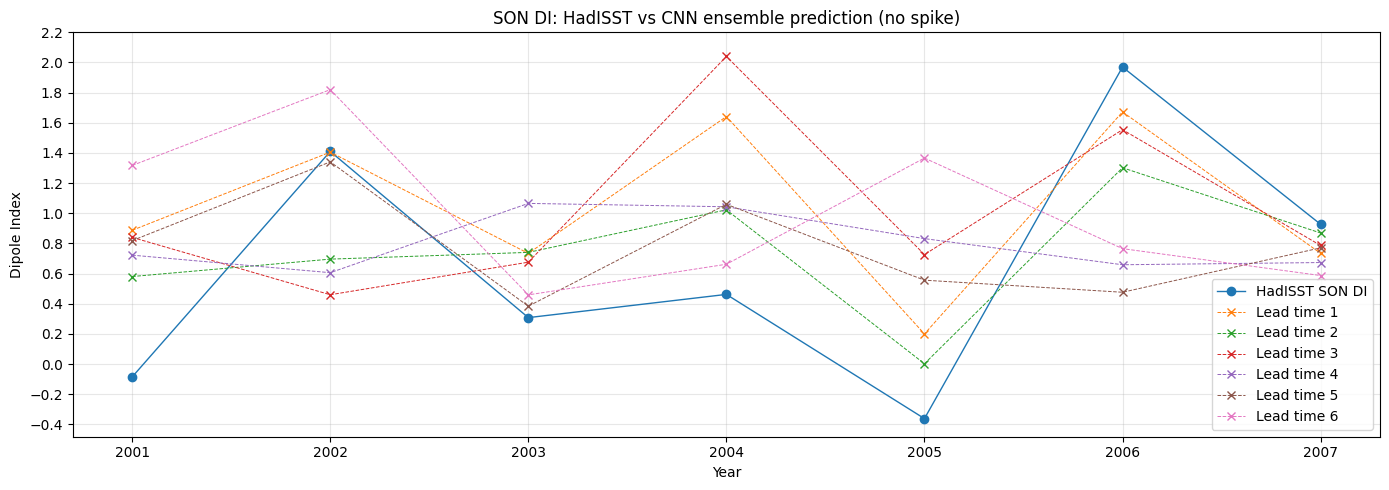

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test.time, y_test, color='C0', marker='o', label='HadISST SON DI', linewidth=1)

# Define the color list for each lead time
color_list = ['C1','C2','C3','C4','C5','C6']
for i in range(len(results_per_leadtime_testing)):
    ax.plot(y_test.time, results_per_leadtime_testing[i+1]['ensemble_no_spike_prediction'], color=color_list[i], marker='x', linestyle='--',lw=0.7,label=f'Lead time {i+1}')

ax.set_xticks(y_test.time.values)
ax.set_yticks(np.arange(-0.4,2.4,0.2))
ax.set_xlabel('Year')
ax.set_ylabel('Dipole Index')
ax.set_title('SON DI: HadISST vs CNN ensemble prediction (no spike)')
ax.legend(loc='best')
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

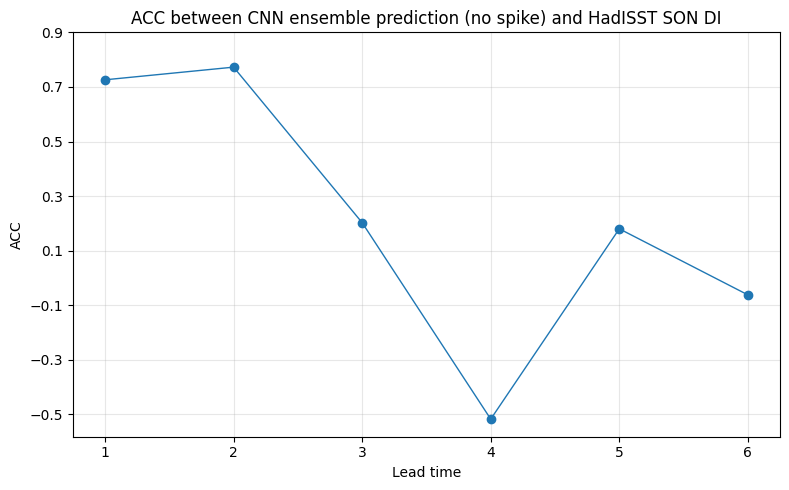

In [29]:
acc_values = []
for i in range(len(results_per_leadtime_testing)):
    pred = results_per_leadtime_testing[i+1]['ensemble_no_spike_prediction']
    acc = xs.pearson_r(pred, y_test, dim='time').values
    acc_values.append(acc)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1,len(results_per_leadtime_testing)+1), acc_values, marker='o', color='C0', linewidth=1)
ax.set_xlabel('Lead time')
ax.set_ylabel('ACC')
ax.set_title('ACC between CNN ensemble prediction (no spike) and HadISST SON DI')
ax.set_xticks(np.arange(1,len(results_per_leadtime_testing)+1))
ax.set_yticks(np.arange(-0.5,1.0,0.2))
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()